# Trabajo Fin de Máster
## Business Analytics aplicado a FOOD&FUN: análisis, predicción y optimización para la toma de decisiones

## Gestión de Asistentes y Eventos

**Autora:** Francisca Concha

**Máster en Business Analytics e Inteligencia de Negocio**

**Universidad Católica de Valencia**

**Curso académico 2025–2026**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

ruta = "/Users/fran/Desktop/UCV Master /TFM/TFM VSC/Compras_2526_F&F.xlsx"

df = pd.read_excel(ruta)

print(df.shape)
print(df.columns.tolist())

(1409, 9)
['Fecha de Compra', 'Número de Pedido', 'Taller', 'Fecha Taller', 'Cantidad de Plazas', 'TARJETAS REGALO', 'Importe Total', 'IMPORTE DEVOLUCIÓN', 'Método de Pago']


In [3]:
df["Fecha Taller"].head(20)

0                     NaN
1     2025-03-24 00:00:00
2                     NaN
3                     NaN
4     2025-03-28 00:00:00
5     2025-02-07 00:00:00
6                     NaN
7                     NaN
8                     NaN
9                     NaN
10    2025-03-29 00:00:00
11                    NaN
12                    NaN
13    2025-02-14 00:00:00
14                    NaN
15    2025-03-29 00:00:00
16    2025-03-29 00:00:00
17                    NaN
18    2025-03-21 00:00:00
19    2025-02-05 00:00:00
Name: Fecha Taller, dtype: object

In [4]:
eventos_df = df.dropna(subset=["Fecha Taller"]).copy()

In [5]:
df

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago
0,2024-11-18,43856526,Tarjeta Regalo,NaN,0,1.0,150.0,NaN,Visa
1,2025-01-01,43861545,Kimchi,2025-03-24 00:00:00,2,NaN,180.0,NaN,Bizum
2,2025-01-01,43861547,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa
3,2025-01-01,43861597,Tarjeta Regalo,NaN,0,0.0,0.0,NaN,Devolución
4,2025-01-01,43861549,Ramen,2025-03-28 00:00:00,2,NaN,162.0,NaN,Visa
...,...,...,...,...,...,...,...,...,...
1404,2026-05-29,1015,Curso de Arroces,2026-06-20 00:00:00,1,NaN,70.0,NaN,Shopify
1405,2026-05-29,1015,Paella Lovers,2026-06-06 00:00:00,2,NaN,140.0,NaN,Shopify
1406,2026-05-29,81672,Curso de Arroces,2026-05-31 00:00:00,1,NaN,0.0,NaN,Tarjeta Regalo (canjeado)
1407,2026-06-01,1024,Tapas Españolas,2026-06-05 00:00:00,1,NaN,81.0,NaN,Shopify


In [6]:
print("Registros originales:", len(df))
print("Registros con fecha de taller:", len(eventos_df))

Registros originales: 1409
Registros con fecha de taller: 1029


In [7]:
eventos = (
    eventos_df
    .groupby(["Fecha Taller", "Taller"])
    .agg({
        "Número de Pedido": "nunique",
        "Cantidad de Plazas": "sum",
        "Importe Total": "sum"
    })
    .reset_index()
)

eventos.columns = [
    "Fecha Taller",
    "Taller",
    "Reservas",
    "Plazas Vendidas",
    "Ingresos"
]

eventos.head()

,Fecha Taller,Taller,Reservas,Plazas Vendidas,Ingresos
0,2025-01-11 00:00:00,Paella Lovers,5,13,840.0
1,2025-01-18 00:00:00,Curso de Arroces,1,1,90.0
2,2025-01-24 00:00:00,Sushi,2,3,270.0
3,2025-02-01 00:00:00,Raíces,1,1,90.0
4,2025-02-03 00:00:00,Taller de Principiantes,4,4,500.0


In [8]:
eventos.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fecha Taller     162 non-null    object 
 1   Taller           162 non-null    str    
 2   Reservas         162 non-null    int64  
 3   Plazas Vendidas  162 non-null    int64  
 4   Ingresos         162 non-null    float64
dtypes: float64(1), int64(2), object(1), str(1)
memory usage: 8.6+ KB


In [9]:
eventos["Fecha Taller"].apply(type).value_counts()

Fecha Taller
<class 'datetime.datetime'>    159
<class 'str'>                    3
Name: count, dtype: int64

In [10]:
eventos[
    eventos["Fecha Taller"].apply(lambda x: isinstance(x, str))
]

,Fecha Taller,Taller,Reservas,Plazas Vendidas,Ingresos
159,LISTA DE ESPERA,Cocas Miquel Ruiz,1,0,0.0
160,octubre,Cocas Miquel Ruiz,1,0,0.0
161,prueba,Curso Cocina Mexicana,1,1,80.0


In [11]:
eventos["Fecha Taller"] = pd.to_datetime(
    eventos["Fecha Taller"],
    errors="coerce"
)

eventos = eventos.dropna(subset=["Fecha Taller"]).copy()

In [12]:
eventos["Fecha Taller"].apply(type).value_counts()

Fecha Taller
<class 'pandas.Timestamp'>    159
Name: count, dtype: int64

In [13]:
eventos = eventos.sort_values("Fecha Taller")

eventos.tail(20)

,Fecha Taller,Taller,Reservas,Plazas Vendidas,Ingresos
139,2026-05-15,Ramen,9,11,810.0
140,2026-05-16,Curso de Arroces,10,14,900.0
141,2026-05-22,Taller de Pasta Fresca,3,6,360.0
142,2026-05-23,Reposteria,6,8,630.0
143,2026-05-30,Croquetas,2,3,250.0
144,2026-05-31,Curso de Arroces,9,12,450.0
145,2026-06-05,Tapas Españolas,3,9,261.0
146,2026-06-06,Paella Lovers,3,4,230.0
147,2026-06-07,Reposteria,3,4,270.0
148,2026-06-12,Sushi,8,16,1440.0


In [14]:
eventos.head(20)

,Fecha Taller,Taller,Reservas,Plazas Vendidas,Ingresos
0,2025-01-11,Paella Lovers,5,13,840.0
1,2025-01-18,Curso de Arroces,1,1,90.0
2,2025-01-24,Sushi,2,3,270.0
3,2025-02-01,Raíces,1,1,90.0
4,2025-02-03,Taller de Principiantes,4,4,500.0
5,2025-02-05,Tapas Españolas,7,16,906.0
6,2025-02-05,Tarjeta Regalo,1,0,126.0
7,2025-02-07,Ramen,1,1,90.0
9,2025-02-08,Tarjeta Regalo,1,0,140.0
8,2025-02-08,Paella Lovers,9,13,570.0


In [15]:
eventos.columns

Index(['Fecha Taller', 'Taller', 'Reservas', 'Plazas Vendidas', 'Ingresos'], dtype='str')

In [16]:
eventos.sample(5)

,Fecha Taller,Taller,Reservas,Plazas Vendidas,Ingresos
52,2025-06-06,Tapas Españolas,5,9,560.0
69,2025-09-12,Curso Cocina Mexicana,1,0,0.0
36,2025-04-12,Tarjeta Regalo,1,0,140.0
78,2025-10-04,Paella Lovers,7,12,960.0
17,2025-03-01,Tarjeta Regalo,1,0,140.0


In [17]:
eventos = (
    eventos_df
    .groupby(["Fecha Taller", "Taller"])
    .agg({
        "Cantidad de Plazas": "sum",
        "Importe Total": "sum"
    })
    .reset_index()
)

eventos.columns = [
    "Fecha Taller",
    "Taller",
    "Plazas Vendidas",
    "Ingresos"
]

In [18]:
eventos["Fecha Taller"] = pd.to_datetime(
    eventos["Fecha Taller"],
    errors="coerce"
)

eventos = eventos.dropna(subset=["Fecha Taller"])

In [19]:
eventos = eventos.sort_values("Fecha Taller")

eventos.tail(20)

,Fecha Taller,Taller,Plazas Vendidas,Ingresos
139,2026-05-15,Ramen,11,810.0
140,2026-05-16,Curso de Arroces,14,900.0
141,2026-05-22,Taller de Pasta Fresca,6,360.0
142,2026-05-23,Reposteria,8,630.0
143,2026-05-30,Croquetas,3,250.0
144,2026-05-31,Curso de Arroces,12,450.0
145,2026-06-05,Tapas Españolas,9,261.0
146,2026-06-06,Paella Lovers,4,230.0
147,2026-06-07,Reposteria,4,270.0
148,2026-06-12,Sushi,16,1440.0


In [20]:
df["Taller"].unique()

<ArrowStringArray>
[              'Tarjeta Regalo',                       'Kimchi',
                        'Ramen',                       'Raíces',
       'Taller de Pasta Fresca',              'Tapas Españolas',
                        'Sushi',                'Paella Lovers',
             'Curso de Arroces',      'Taller de Principiantes',
              'Taller de Curry',                   'Reposteria',
            'Cocas Miquel Ruiz',        'Curso Cocina Mexicana',
 'Esperando selección de curso',                        'NOBLE',
         'Clasicos Valencianos',                    'Croquetas']
Length: 18, dtype: str

In [21]:
detalle_eventos = (
    df.dropna(subset=["Fecha Taller"])
      .groupby([
          "Taller",
          "Fecha Taller",
          "Número de Pedido"
      ])
      .agg({
          "Cantidad de Plazas": "sum",
          "Importe Total": "sum"
      })
      .reset_index()
)

detalle_eventos.columns = [
    "Taller",
    "Fecha Taller",
    "Número Pedido",
    "Plazas Reservadas",
    "Ingresos"
]

detalle_eventos = detalle_eventos.sort_values(
    ["Taller", "Fecha Taller"]
)

detalle_eventos.head(20)

,Taller,Fecha Taller,Número Pedido,Plazas Reservadas,Ingresos
0,Clasicos Valencianos,2026-03-29 00:00:00,43877745,0,0.0
1,Clasicos Valencianos,2026-06-13 00:00:00,81627,1,90.0
2,Clasicos Valencianos,2026-06-13 00:00:00,81645,1,0.0
3,Clasicos Valencianos,2026-06-13 00:00:00,43878171,1,0.0
4,Cocas Miquel Ruiz,2025-07-12 00:00:00,15,2,190.0
5,Cocas Miquel Ruiz,2025-07-12 00:00:00,26,1,95.0
6,Cocas Miquel Ruiz,2025-07-12 00:00:00,29,1,5.0
7,Cocas Miquel Ruiz,2025-07-12 00:00:00,43867980,2,190.0
8,Cocas Miquel Ruiz,2025-07-12 00:00:00,43869220,1,0.0
9,Cocas Miquel Ruiz,2025-07-12 00:00:00,43869221,1,0.0


In [23]:
# Día de compra

dias = {
    "Monday":"Lunes",
    "Tuesday":"Martes",
    "Wednesday":"Miércoles",
    "Thursday":"Jueves",
    "Friday":"Viernes",
    "Saturday":"Sábado",
    "Sunday":"Domingo"
}

df["Fecha de Compra"] = pd.to_datetime(df["Fecha de Compra"])

df["Dia Compra"] = (
    df["Fecha de Compra"]
    .dt.day_name()
    .map(dias)
)

# Fecha taller

df["Fecha Taller"] = pd.to_datetime(
    df["Fecha Taller"],
    errors="coerce"
)

# Antelación

df["Antelacion Dias"] = (
    df["Fecha Taller"]
    - df["Fecha de Compra"]
).dt.days


/var/folders/fd/qpyzc0v159bblqkhjd540pr80000gn/T/ipykernel_55072/1185048125.py:23: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Fecha Taller"] = pd.to_datetime(


In [24]:
df.head()

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago,Dia Compra,Antelacion Dias
0,2024-11-18,43856526,Tarjeta Regalo,NaT,0,1.0,150.0,NaN,Visa,Lunes,NaN
1,2025-01-01,43861545,Kimchi,2025-03-24,2,NaN,180.0,NaN,Bizum,Miércoles,82.0
2,2025-01-01,43861547,Tarjeta Regalo,NaT,0,1.0,90.0,NaN,Visa,Miércoles,NaN
3,2025-01-01,43861597,Tarjeta Regalo,NaT,0,0.0,0.0,NaN,Devolución,Miércoles,NaN
4,2025-01-01,43861549,Ramen,2025-03-28,2,NaN,162.0,NaN,Visa,Miércoles,86.0


In [25]:
df["Mes Taller"] = df["Fecha Taller"].dt.month_name()


In [26]:
meses = {
    "January":"Enero",
    "February":"Febrero",
    "March":"Marzo",
    "April":"Abril",
    "May":"Mayo",
    "June":"Junio",
    "July":"Julio",
    "August":"Agosto",
    "September":"Septiembre",
    "October":"Octubre",
    "November":"Noviembre",
    "December":"Diciembre"
}

df["Mes Taller"] = (
    df["Fecha Taller"]
    .dt.month_name()
    .map(meses)
)

In [27]:
df["Importe Neto"] = (
    df["Importe Total"]
    - df["IMPORTE DEVOLUCIÓN"].fillna(0)
)

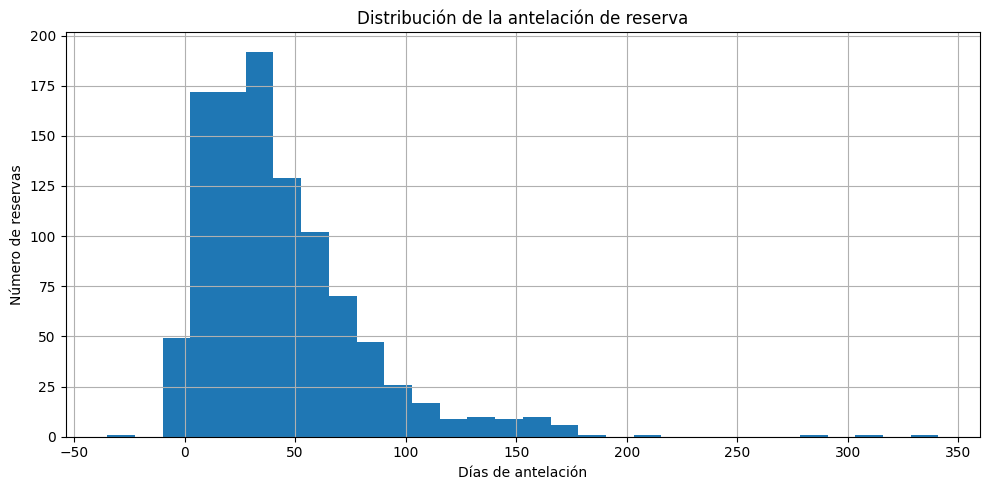

In [28]:
plt.figure(figsize=(10,5))

df["Antelacion Dias"].hist(bins=30)

plt.title("Distribución de la antelación de reserva")
plt.xlabel("Días de antelación")
plt.ylabel("Número de reservas")

plt.tight_layout()
plt.show()

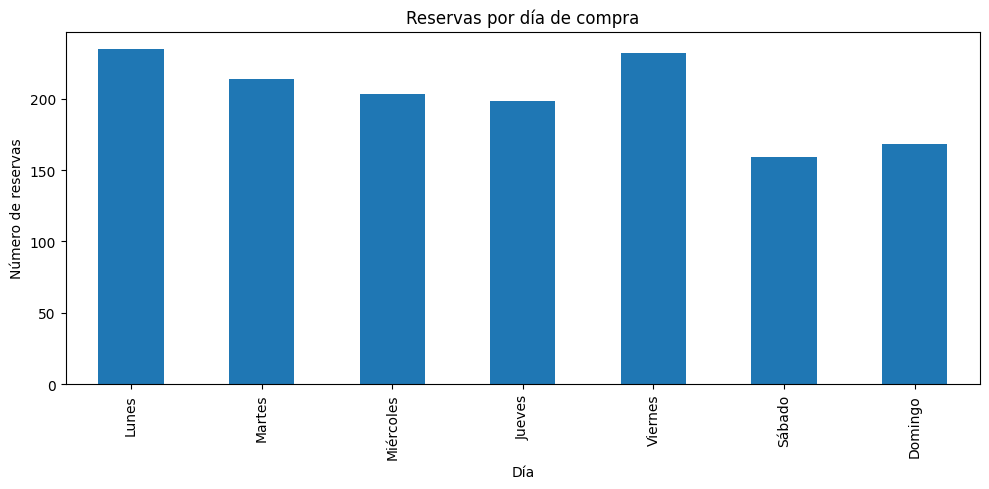

In [29]:
compras_dia = (
    df["Dia Compra"]
    .value_counts()
    .reindex([
        "Lunes",
        "Martes",
        "Miércoles",
        "Jueves",
        "Viernes",
        "Sábado",
        "Domingo"
    ])
)

plt.figure(figsize=(10,5))

compras_dia.plot(kind="bar")

plt.title("Reservas por día de compra")
plt.xlabel("Día")
plt.ylabel("Número de reservas")

plt.tight_layout()
plt.show()

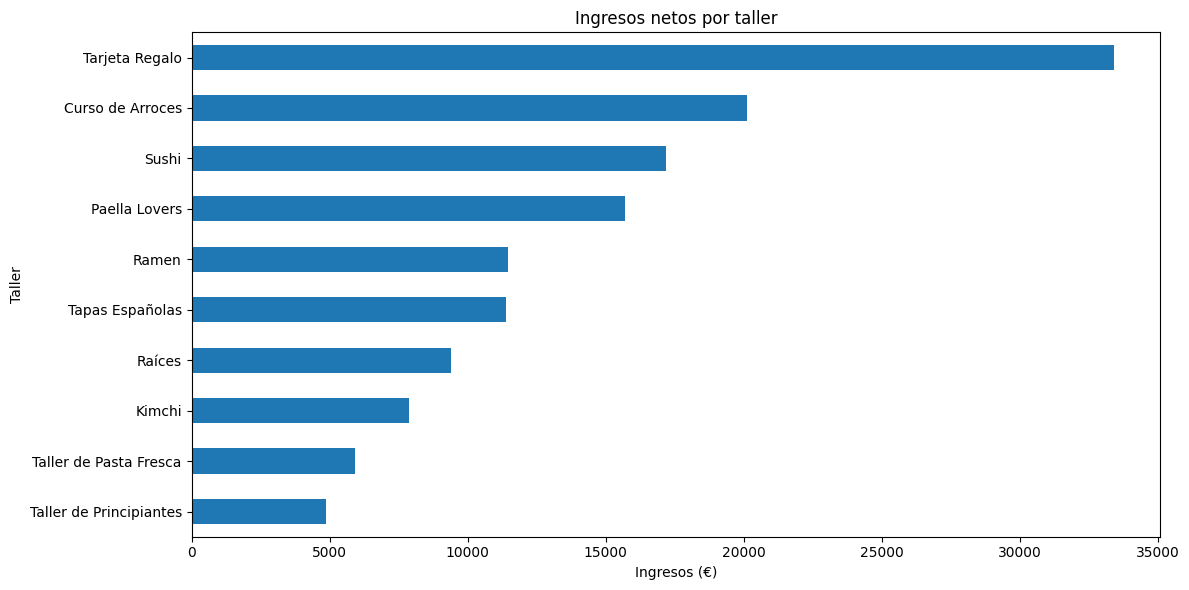

In [30]:
ingresos_taller = (
    df.groupby("Taller")["Importe Neto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ingresos_taller.sort_values().plot(kind="barh")

plt.title("Ingresos netos por taller")
plt.xlabel("Ingresos (€)")
plt.ylabel("Taller")

plt.tight_layout()
plt.show()

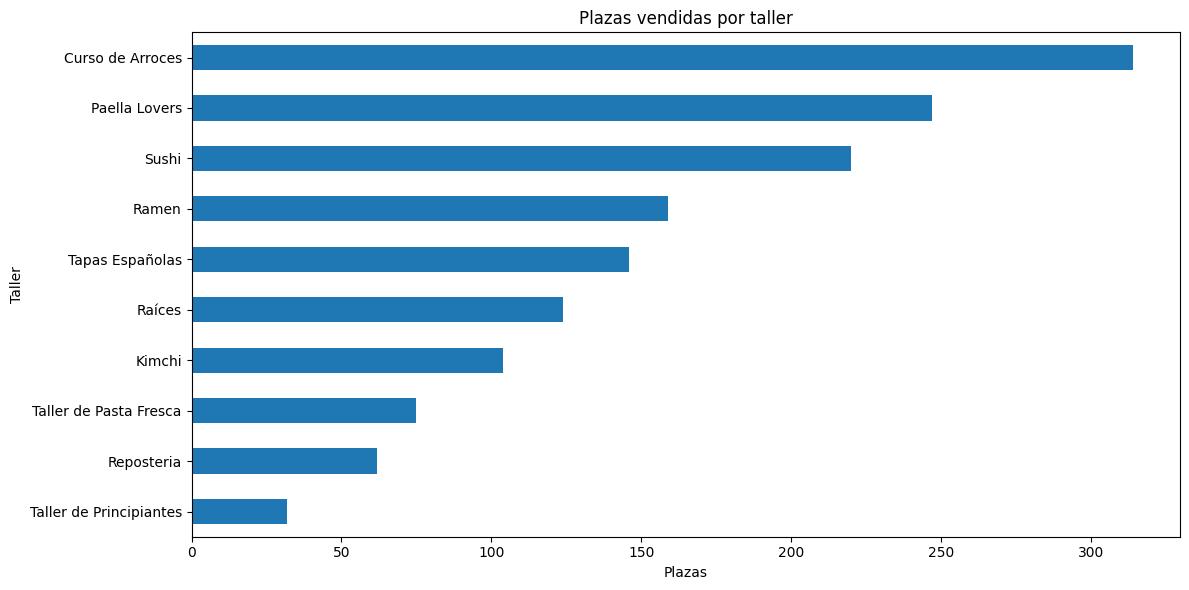

In [31]:
plazas_taller = (
    df.groupby("Taller")["Cantidad de Plazas"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plazas_taller.sort_values().plot(kind="barh")

plt.title("Plazas vendidas por taller")
plt.xlabel("Plazas")
plt.ylabel("Taller")

plt.tight_layout()
plt.show()

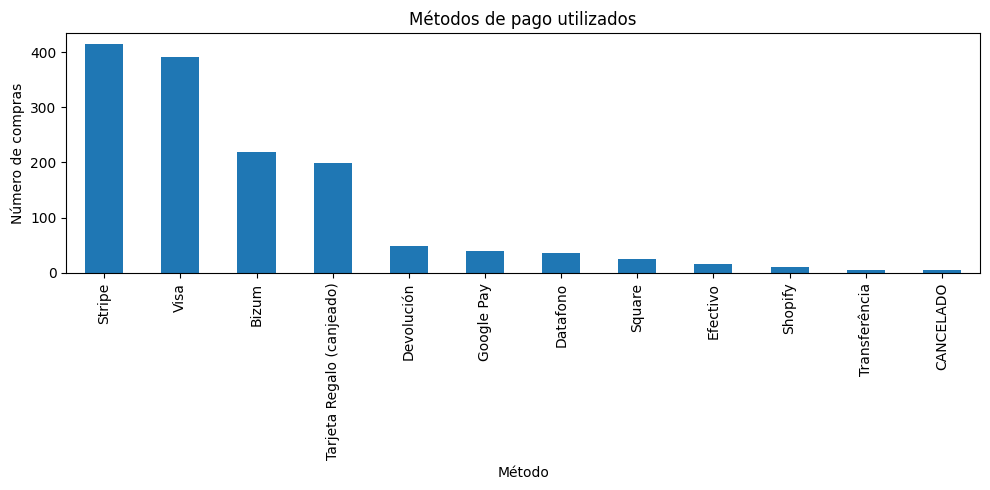

In [32]:
pagos = df["Método de Pago"].value_counts()

plt.figure(figsize=(10,5))

pagos.plot(kind="bar")

plt.title("Métodos de pago utilizados")
plt.xlabel("Método")
plt.ylabel("Número de compras")

plt.tight_layout()
plt.show()

In [33]:
df["Fecha Taller"] = (
    df["Fecha Taller"]
    .dt.strftime("%d/%m/%Y")
)

In [34]:
df.to_excel(
    "FoodFun_Analytics_Operativo.xlsx",
    index=False
)